# Всероссийская студенческая Актионада – Кейс-чемпионат «РЕСТАРТ» 2025 по направлению «IT» 2 этап

## Задание 1. Классификация ежедневных транзакций — на основе Daily Transactions Dataset

**Описание задачи:** У компании есть выгрузка ежедневных транзакций: дата/время, сумма, способ оплаты, категория и подкатегория покупки, текстовое примечание. В реальности разметку класса операции выполняют специалисты вручную — долго и с риском ошибок.

Каждая транзакция должна быть отнесена к одному из классов транзакции — например: «здоровье», «одежда», «налоги», «аренда», «командировочные расходы» и т.д.

**Данные:**

- `Date`: дата и время совершения транзакции
- `Mode`: способ оплаты
- `Category`: каждая запись относится к определённой категории транзакций
- `Subcategory`: категории дополнительно разбиваются на подкатегории
- `Note`: краткая информация о проведённой операции
- `Amount`: сумма операции
- `Income/Expense`: каждая операция обозначается как расход или доход
- `Currency`: все операции фиксируются в официальной валюте Индии

**Метрика оценки качества:**

Macro F1-score (среднее макро по всем категориям).

**Задания:**

1. На основе предоставленного датасета провести анализ, который должен включать:

- Распределение целевой переменной `Category` (число классов, уровень дисбаланса).
- Анализ пропущенных значений во всех признаках.
- Статистический анализ признака `Amount` (распределение, выбросы, различия для доходов/расходов).
- Анализ признака `Category` (топ-10 самых частых контрагентов).

2. Разработать и реализовать код пайплайна, который выполняет:

- Обработку пропущенных значений в текстовых полях заполнением строкой 'UNKNOWN'.
- Извлечение из Date как минимум трех новых признаков (например, день недели, месяц, является ли день выходным).
- Векторизацию текстового поля `Note` с помощью метода CountVectorizer с параметрами по умолчанию.
- Объединение всех признаков (числовых, категориальных, временных, текстовых) в единую матрицу для обучения.

### Загрузка и обзор данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from catboost import CatBoostClassifier

In [2]:
try:
    df = pd.read_csv('Daily Household Transactions.csv')
except:
    df = pd.read_csv(r'C:\ds_projects\actionada\Task_1\Daily Household Transactions.csv')
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   str    
 1   Mode            2461 non-null   str    
 2   Category        2461 non-null   str    
 3   Subcategory     1826 non-null   str    
 4   Note            1940 non-null   str    
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   str    
 7   Currency        2461 non-null   str    
dtypes: float64(1), str(7)
memory usage: 153.9 KB


In [4]:
df.describe(include='all')

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
count,2461,2461,2461,1826,1940,2461.000000,2461,2461
unique,1611,12,50,90,1057,NaN,3,1
top,1/5/2017,Saving Bank account 1,Food,Milk,milk 1lit,NaN,Expense,INR
freq,11,1223,907,162,67,NaN,2176,2461
mean,NaN,NaN,NaN,NaN,NaN,2751.145380,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,12519.615804,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,799.000000,NaN,NaN


In [5]:
df.isna().sum()

Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

In [6]:
print('Полных дубликатов в датасете:', df.duplicated().sum())

Полных дубликатов в датасете: 9


**Промежуточный вывод:** В ходе обзора данных были выявлены 9 полных дубликатов и строковый тип данных в столбце `Date`. И ещё были зафиксированы пропуски в столбцах `Subcategory` и `Note`. Также стандартное отклонение и максимальное значение в столбце `Amount` на фоне остальных значений выглядят крайне высокими. Смею предположить, что распределение скошено вправо.

### Предобработка данных

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
display(df.head())
df.dtypes

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,2018-09-20 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,2018-09-20 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,2018-09-19 00:00:00,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,2018-09-17 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,2018-09-16 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


Date              datetime64[us]
Mode                         str
Category                     str
Subcategory                  str
Note                         str
Amount                   float64
Income/Expense               str
Currency                     str
dtype: object

In [9]:
df_pass_subcategory = df[df['Subcategory'].isna()]
df_pass_subcategory

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
8,2018-09-13 21:01:47,Credit Card,Other,NaN,HBR 2 Months subscription,83.0,Expense,INR
10,2018-09-13 00:00:00,Saving Bank account 1,Small Cap fund 2,NaN,NaN,5000.0,Transfer-Out,INR
11,2018-09-13 00:00:00,Saving Bank account 1,Small cap fund 1,NaN,NaN,5000.0,Transfer-Out,INR
14,2018-09-11 00:00:00,Saving Bank account 1,Other,NaN,From Family,3500.0,Income,INR
19,2018-09-07 00:00:00,Saving Bank account 1,Equity Mutual Fund E,NaN,NaN,1000.0,Transfer-Out,INR
...,...,...,...,...,...,...,...,...
2456,2015-01-01 00:00:00,Cash,Transportation,NaN,share jeep - Place T base to top,20.0,Expense,INR
2457,2015-01-01 00:00:00,Cash,Transportation,NaN,share auto - Place H to Place T base,20.0,Expense,INR
2458,2015-01-01 00:00:00,Cash,Transportation,NaN,bus - brc to Place H,30.0,Expense,INR
2459,2015-01-01 00:00:00,Cash,Food,NaN,tea,10.0,Expense,INR


Category
Other                        126
Food                          85
Salary                        43
Recurring Deposit             41
Gift                          30
Public Provident Fund         29
Money transfer                28
Transportation                24
Equity Mutual Fund E          22
Gpay Reward                   21
Saving Bank account 1         17
maid                          17
Equity Mutual Fund A          14
Equity Mutual Fund F          13
Dividend earned on Shares     12
Interest                      12
Small Cap fund 2              10
Small cap fund 1              10
Share Market                   8
Life Insurance                 7
Maturity amount                7
Petty cash                     6
Equity Mutual Fund C           6
Bonus                          6
Rent                           4
Cook                           4
Saving Bank account 2          3
water (jar /tanker)            3
Household                      3
Tax refund                     2
S

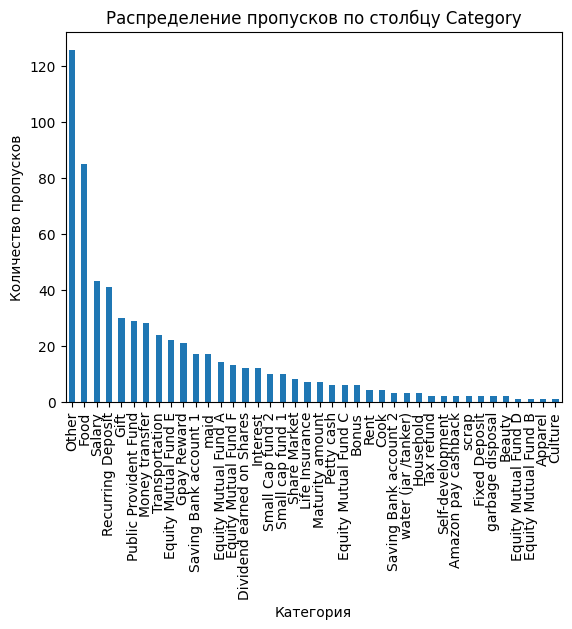

In [10]:
missing_by_category = df_pass_subcategory['Category'].value_counts()
print(missing_by_category)

missing_by_category.plot(kind='bar')
plt.title('Распределение пропусков по столбцу Category')
plt.xlabel('Категория')
plt.ylabel('Количество пропусков')
plt.show()

In [11]:
df['Category'].value_counts()

Category
Food                         906
Transportation               307
Household                    176
subscription                 143
Other                        126
Investment                   101
Health                        94
Family                        71
Apparel                       47
Salary                        43
Money transfer                43
Recurring Deposit             41
Gift                          30
Public Provident Fund         29
Equity Mutual Fund E          22
Beauty                        22
Gpay Reward                   21
Education                     18
Saving Bank account 1         17
maid                          17
Festivals                     16
Equity Mutual Fund A          14
Equity Mutual Fund F          13
Dividend earned on Shares     12
Interest                      12
Culture                       11
Small Cap fund 2              10
Small cap fund 1              10
Share Market                   8
Life Insurance                 7
M

**Вывод по графику:** В категории `Other` в столбце `Subcategory` все значения пропущены. Это наталкивает на вывод, что подкатегорий в этой категории не существует. 

In [12]:
df = df.fillna('UNKNOWN')
df.isna().sum()

Date              0
Mode              0
Category          0
Subcategory       0
Note              0
Amount            0
Income/Expense    0
Currency          0
dtype: int64

**Промежуточный вывод по предобработке данных:** дубликаты удалены, тип данных заменён на datetime, пропуски заполнены. Можно приступать к исследовательскому анализу данных.

### Исследовательский анализ данных

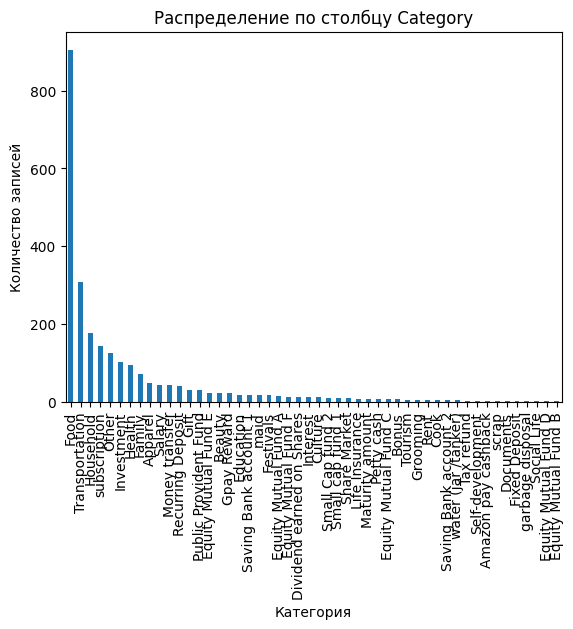

In [13]:
df['Category'].value_counts().plot(kind='bar')
plt.title('Распределение по столбцу Category')
plt.xlabel('Категория')
plt.ylabel('Количество записей')
plt.show()

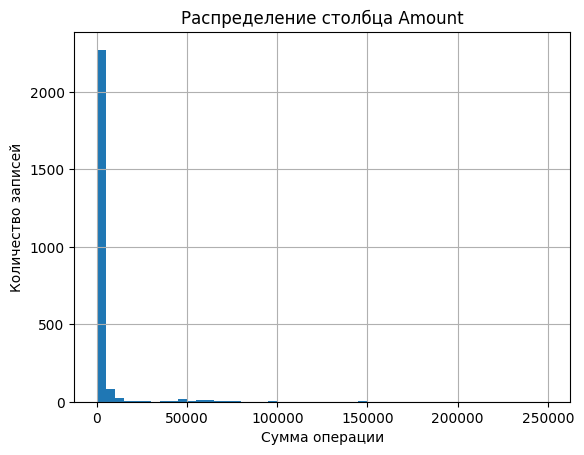

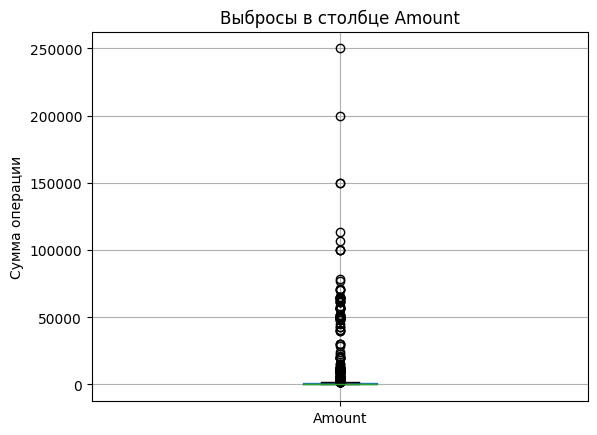

In [14]:
df['Amount'].hist(bins=50)
plt.title('Распределение столбца Amount')
plt.xlabel('Сумма операции')
plt.ylabel('Количество записей')
plt.show()

df.boxplot()
plt.title('Выбросы в столбце Amount')
plt.ylabel('Сумма операции')
plt.show()

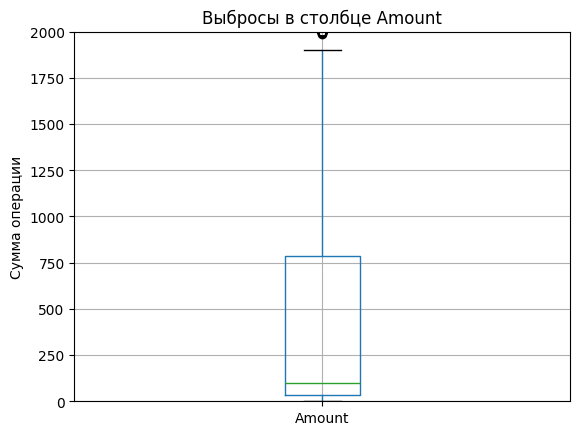

In [15]:
df.boxplot()
plt.ylim(0, 2000) #Задаю лимиты по y, чтобы лучше увидеть сам ящик с усами
plt.title('Выбросы в столбце Amount')
plt.ylabel('Сумма операции')
plt.show()

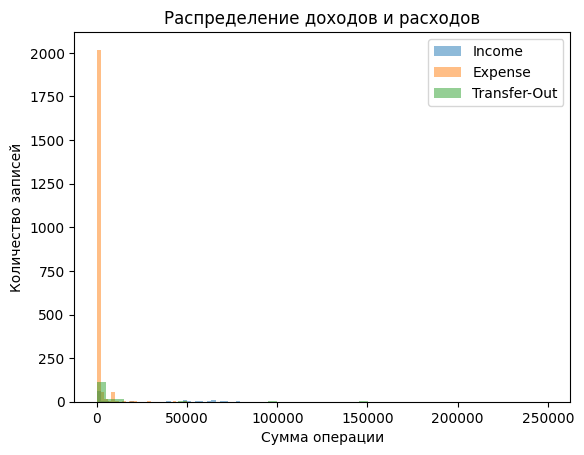

In [16]:
df_income = df[df['Income/Expense'] == 'Income']
df_expense = df[df['Income/Expense'] == 'Expense']
df_transfer = df[df['Income/Expense'] == 'Transfer-Out']
plt.hist(df_income['Amount'], alpha=0.5, label='Income', bins=50)
plt.hist(df_expense['Amount'], alpha=0.5, label='Expense', bins=50)
plt.hist(df_transfer['Amount'], alpha=0.5, label='Transfer-Out', bins=50)
plt.legend()
plt.title('Распределение доходов и расходов')
plt.xlabel('Сумма операции')
plt.ylabel('Количество записей')
plt.show()

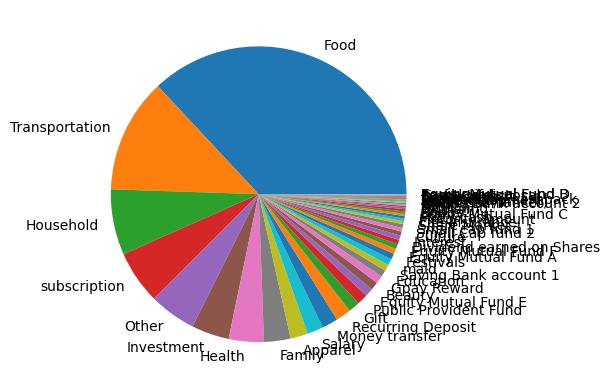

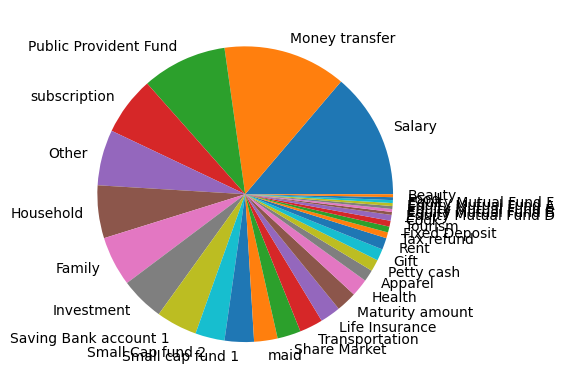

In [17]:
df['Category'].value_counts().plot(kind='pie')
plt.show()
df_outlier = df[df['Amount'] >= 2000]
df_outlier['Category'].value_counts().plot(kind='pie')
plt.show()

In [18]:
print('Количество выбросов:', len(df[df['Amount'] >= 2000]))
print('Количество записей без учёта выбросов:', len(df[df['Amount'] < 2000]))

Количество выбросов: 312
Количество записей без учёта выбросов: 2140


**Промежуточный вывод по исследовательскому анализу данных:** 
- Большая часть записей относится к категории Food.
- Гипотеза о скошенности значений столбца `Amount` вправо подтвердилась.
- Также было замечено большое количество выбросов, начиная с значения примерно 2000 и до 250000, в этом столбце.
- Диаграмма распределения доход и расходов показала, что большая часть операций это именно расходы. 

А самый интересный момент виден на круговых диаграммах. На общей диаграмме самые популярные категории это Food, Household и Transparation, то есть бытовая категория. А на диаграмме выбросов самые популярные категории это Salary, Money transfer и Public Provident Fund, то есть финансовая категория. И это выглядит логично, так как большая часть операций с финансами небольшие (как раз бытовые операции), которые действительно случаются в жизни чаще, а финансовых операций меньше (зарплата платится каждый месяц), но они крупнее, поэтому на фоне бытовых операций они и выглядят как выбросы.

### Подготовка данных для машинного обучения и сборка пайплайна

In [19]:
rare_values = df['Category'].value_counts()[df['Category'].value_counts() < 10].index
df.loc[df['Category'].isin(rare_values), 'Category'] = 'Other'
df['Category'].value_counts()

Category
Food                         906
Transportation               307
Other                        206
Household                    176
subscription                 143
Investment                   101
Health                        94
Family                        71
Apparel                       47
Salary                        43
Money transfer                43
Recurring Deposit             41
Gift                          30
Public Provident Fund         29
Equity Mutual Fund E          22
Beauty                        22
Gpay Reward                   21
Education                     18
Saving Bank account 1         17
maid                          17
Festivals                     16
Equity Mutual Fund A          14
Equity Mutual Fund F          13
Dividend earned on Shares     12
Interest                      12
Culture                       11
Small Cap fund 2              10
Small cap fund 1              10
Name: count, dtype: int64

In [20]:
y = df['Category']
X = df.drop(['Category', 'Subcategory', 'Currency'], axis=1)
X.head()

,Date,Mode,Note,Amount,Income/Expense
0,2018-09-20 12:04:08,Cash,2 Place 5 to Place 0,30.0,Expense
1,2018-09-20 12:03:15,Cash,Idli medu Vada mix 2 plates,60.0,Expense
2,2018-09-19 00:00:00,Saving Bank account 1,1 month subscription,199.0,Expense
3,2018-09-17 23:41:17,Saving Bank account 1,Data booster pack,19.0,Expense
4,2018-09-16 17:15:08,Cash,Ganesh idol,251.0,Expense


In [21]:
X['dayofweek'] = X['Date'].dt.dayofweek
X['month'] = X['Date'].dt.month
X['is_weekend'] = (X['Date'].dt.dayofweek >= 5).astype(int)
X.head()

,Date,Mode,Note,Amount,Income/Expense,dayofweek,month,is_weekend
0,2018-09-20 12:04:08,Cash,2 Place 5 to Place 0,30.0,Expense,3,9,0
1,2018-09-20 12:03:15,Cash,Idli medu Vada mix 2 plates,60.0,Expense,3,9,0
2,2018-09-19 00:00:00,Saving Bank account 1,1 month subscription,199.0,Expense,2,9,0
3,2018-09-17 23:41:17,Saving Bank account 1,Data booster pack,19.0,Expense,0,9,0
4,2018-09-16 17:15:08,Cash,Ganesh idol,251.0,Expense,6,9,1


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [23]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Amount']),
    ('text', TfidfVectorizer(), 'Note'),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Mode', 'dayofweek', 'month', 'Income/Expense']),
    ('bin', 'passthrough', ['is_weekend'])
])

**Пояснение:** Категории, представленные меньше чем 10 записями, я переопределил в Other, т. к. при стратифицированном сплите 75/25 это даёт менее ~3 объектов в тестовой выборке, что не позволяет ни обучить, ни надёжно оценить класс по macro F1. Также я убрал столбцы `Subcategory` и `Currency`. `Subcategory` был убран, потому что во-первых этот столбец создаёт утечку для целевого признака, ведь по нему можно с большой точностью определить категорию, например: подкатегория `snacks` точно указывает на категорию `Food`. Во-вторых `Subcategory` в реальном сценарии недоступна до разметки.

### Обучение моделей

#### LogisticRegression

In [24]:
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=2000))
])

In [25]:
%%time
param_grid_lr = {
    'model__C': [0.1, 1, 10],
    'model__class_weight': [None, 'balanced'],
    'model__solver': ['saga'],
    'model__l1_ratio': [0, 0.5, 1]
}
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print(grid_lr.best_score_, grid_lr.best_params_)

0.49983370438732705 {'model__C': 10, 'model__class_weight': 'balanced', 'model__l1_ratio': 1, 'model__solver': 'saga'}
CPU times: total: 21.7 s
Wall time: 1min 58s


C:\ds_projects\ds_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


#### RandomForestClassifier

In [26]:
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [27]:
%%time
param_rand_rf = {
    'model__n_estimators': [i for i in range(40, 201, 40)],
    'model__class_weight': [None, 'balanced'],
    'model__max_depth': [i for i in range(2, 21, 6)],
    'model__max_features': ['sqrt', 'log2']
} # Грубая подгонка гиперпараметров
rand_rf = RandomizedSearchCV(pipe_rf, param_rand_rf, random_state=42, n_iter=40, cv=5, scoring='f1_macro', n_jobs=-1)
rand_rf.fit(X_train, y_train)
print(rand_rf.best_score_, rand_rf.best_params_)

0.49387620809396415 {'model__n_estimators': 160, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}
CPU times: total: 1.34 s
Wall time: 9.03 s


In [28]:
%%time
param_grid_rf = {
    'model__n_estimators': [i for i in range(160, 241, 20)],
    'model__class_weight': [None, 'balanced'],
    'model__max_depth': [20, 30, None],
    'model__max_features': ['sqrt', 'log2']
} # Тонкая подгонка гиперпараметров
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_score_, grid_rf.best_params_)

0.500531108009876 {'model__class_weight': 'balanced', 'model__max_depth': 30, 'model__max_features': 'log2', 'model__n_estimators': 220}
CPU times: total: 2.23 s
Wall time: 52.3 s


#### CatBoostClassifier

In [29]:
pipe_cb = Pipeline([
    ('prep', preprocessor),
    ('model', CatBoostClassifier(random_state=42, auto_class_weights='Balanced', iterations=200, verbose=False, allow_writing_files=False))
])

In [30]:
%%time
param_grid_cb = {
    'model__learning_rate': [0.03, 0.1, 0.3],
    'model__depth': [2, 4, 6, 8]
} 
grid_cb = GridSearchCV(pipe_cb, param_grid_cb, cv=5, scoring='f1_macro', n_jobs=-1)
grid_cb.fit(X_train, y_train)
print(grid_cb.best_score_, grid_cb.best_params_)

0.46683926646600044 {'model__depth': 6, 'model__learning_rate': 0.3}
CPU times: total: 1min 24s
Wall time: 7min 10s


In [31]:
columns = ['model', 'macro_f1']
data = [['Logistic Regression', grid_lr.best_score_], ['RandomForestClassifier', grid_rf.best_score_], ['CatBoostClassifier', grid_cb.best_score_]]
pivot_table_models = pd.DataFrame(data=data, columns=columns)
pivot_table_models

,model,macro_f1
0,Logistic Regression,0.499834
1,RandomForestClassifier,0.500531
2,CatBoostClassifier,0.466839


**Вывод:** Все модели получили примерно одинаковые Macro F1, даже при переборе различных гиперпараметров и настройке Tfidf. Это наталкивает на мысль, что для данного датасета Macro F1 = 0.5 максимум. Поэтому следует выбрать LogisticRegression, хоть у него результат и ниже на 0.000697, чем у RandomForestClassifier, но настолько небольшая разница, что эти модели можно приравнять. А в таких ситуациях лучше выбирать более простую модель, коей и является LogisticRegression.

### Тестирование LogisticRegression на тестовой выборке

In [32]:
y_pred = grid_lr.best_estimator_.predict(X_test)
print('Macro F1 логистической регрессии на тестовой выборке:', f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Macro F1 логистической регрессии на тестовой выборке: 0.49513030883855874
                           precision    recall  f1-score   support

                  Apparel       0.82      0.75      0.78        12
                   Beauty       0.62      1.00      0.77         5
                  Culture       0.00      0.00      0.00         3
Dividend earned on Shares       1.00      1.00      1.00         3
                Education       0.50      0.60      0.55         5
     Equity Mutual Fund A       0.00      0.00      0.00         3
     Equity Mutual Fund E       0.12      0.20      0.15         5
     Equity Mutual Fund F       0.00      0.00      0.00         3
                   Family       0.12      0.17      0.14        18
                Festivals       0.50      0.25      0.33         4
                     Food       0.93      0.83      0.88       227
                     Gift       0.60      0.86      0.71         7
              Gpay Reward       0.67      0.80      0.

**Итоговый вывод:** Финальная модель — логистическая регрессия, macro F1 на тесте 0.495, почти полностью совпадает с оценкой по кросс-валидации, следствие отсутствия переобучения. Модель уверенно классифицирует представленные категории (Food f1=0.88, Transportation f1=0.96, Salary=1.00), accuracy 0.69. Низкий macro F1 обусловлен классами с 3-10 примерами, неразличимыми при таком объёме данных; это ограничение данных, а не модели, и является предметом отдельной работы с дисбалансом. Весь процесс от подготовки данных для обучения моделей до теста лучшей модели на тестовой выборке, реализован через sklearn Pipeline, что обеспечивает консистентную обработку train/test и воспроизводимость.

In [33]:
grid_lr.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('text', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont